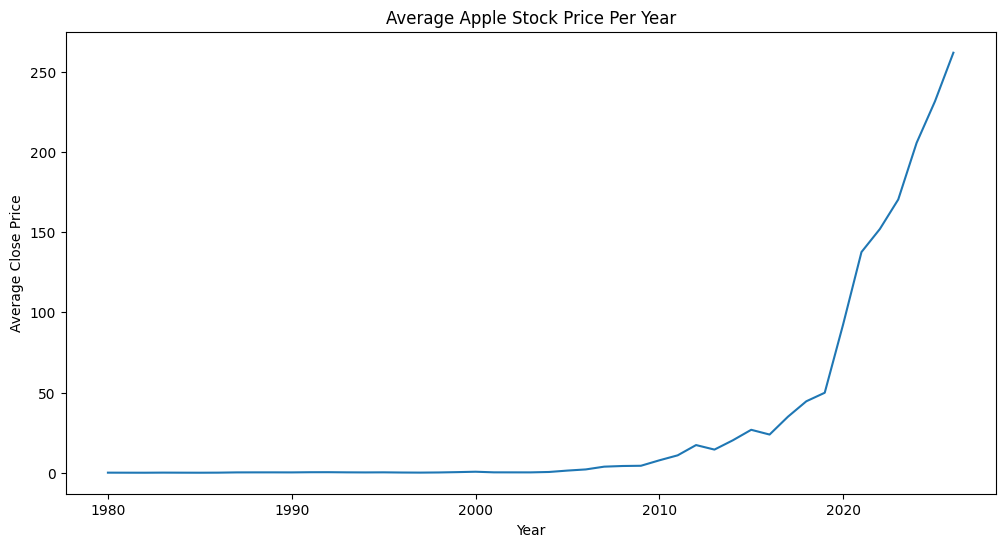

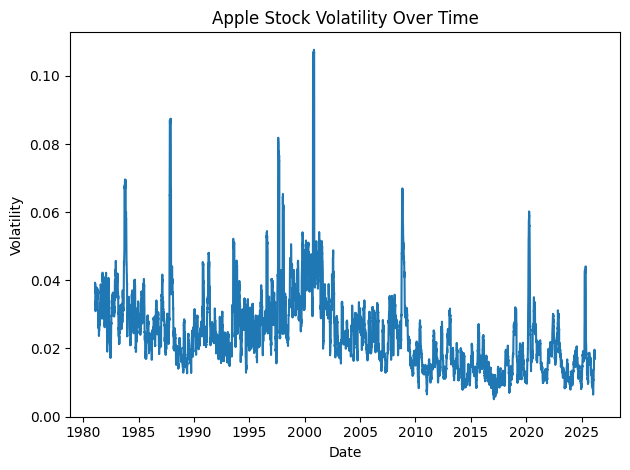

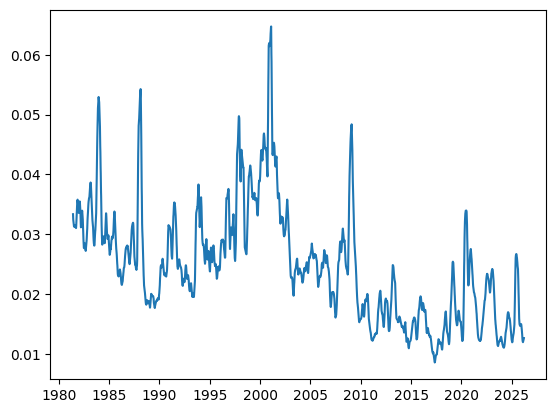

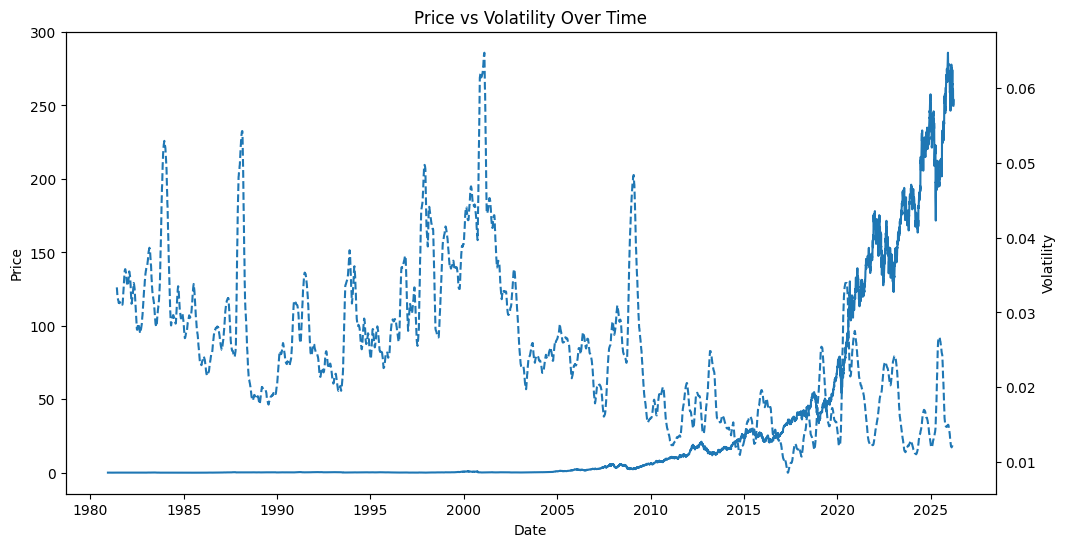

In [19]:
import pandas as pd
df = pd.read_csv('../data/processed/cleaned_stock_data.csv')

df['Date'] = pd.to_datetime(df['Date'])
df['year'] = df['Date'].dt.year
yearly_avg = df.groupby('year')['Close'].mean()


import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(yearly_avg.index, yearly_avg.values)
plt.title("Average Apple Stock Price Per Year")
plt.xlabel("Year")
plt.ylabel("Average Close Price")
plt.show()

df['returns'] = df['Close'].pct_change()
df['volatility'] = df['returns'].rolling(30).std()
plt.plot(df['Date'], df['volatility'])
plt.title("Apple Stock Volatility Over Time")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.tight_layout()
plt.show()

yearly_return = df.groupby('year')['returns'].mean()
df['volatility_smooth'] = df['volatility'].rolling(90).mean()

plt.plot(df['Date'], df['volatility_smooth'])

fig, ax1 = plt.subplots(figsize=(12,6))

# Price (left axis)
ax1.plot(df['Date'], df['Close'], label='Price')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price')

# Volatility (right axis)
ax2 = ax1.twinx()
ax2.plot(df['Date'], df['volatility_smooth'], linestyle='--', label='Volatility')
ax2.set_ylabel('Volatility')

plt.title("Price vs Volatility Over Time")
plt.show()